In [6]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 420
VALIDATION_SIZE = 0.20

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [7]:
DATA_PATH = Path("../week6/data_versions/v6_all_features.csv.gz")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH.resolve()}\n"
        "Please update DATA_PATH to the correct Week 6 CSV file."
    )

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print(f"File: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())

DATASET LOADED
File: ../week6/data_versions/v6_all_features.csv.gz
Rows: 74,403
Columns: 995


,ViewYN,PoolPrivateYN,Latitude,Longitude,LivingArea,DaysOnMarket,AttachedGarageYN,ParkingTotal,YearBuilt,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,Stories,MainLevelBedrooms,NewConstructionYN,GarageSpaces,AssociationFee,LotSizeSquareFeet,MLSAreaMajor_101 - North Inglewood,MLSAreaMajor_102 - South Inglewood,MLSAreaMajor_103 - Ladera Heights,MLSAreaMajor_105 - Lennox,MLSAreaMajor_106 - Los Angeles,MLSAreaMajor_107 - Holly Glen/Del Aire,MLSAreaMajor_108 - North Hawthorne,MLSAreaMajor_109 - Ramona/Burleigh,MLSAreaMajor_11 - Westside,MLSAreaMajor_110 - East Hawthorne,MLSAreaMajor_111 - Bodger Park/El Camino,MLSAreaMajor_112 - North Lawndale,MLSAreaMajor_113 - South Lawndale,MLSAreaMajor_114 - Hollypark,MLSAreaMajor_115 - North Gardena,MLSAreaMajor_116 - North Gateway,MLSAreaMajor_117 - McCarthy,MLSAreaMajor_118 - Pacific Square,MLSAreaMajor_119 - Central Gardena,MLSAreaMajor_120 - South Gardena,MLSAreaMajor_121 - Lomita,MLSAreaMajor_122 - Harbor Gateway,MLSAreaMajor_123 - County Strip,MLSAreaMajor_124 - Harbor City,MLSAreaMajor_125 - Walteria,MLSAreaMajor_126 - Central Torrance,MLSAreaMajor_127 - South East Torrance - West,MLSAreaMajor_128 - Hollywood Riviera,MLSAreaMajor_129 - South Torrance,MLSAreaMajor_130 - Southwood,MLSAreaMajor_131 - West Torrance,MLSAreaMajor_132 - N Torrance - West,...,MLSAreaMajor_VG - Valley Glen,MLSAreaMajor_VIC - Victorville,MLSAreaMajor_VLWC - Valencia West Creek,MLSAreaMajor_VLWH - Valencia West Hills,MLSAreaMajor_VMET - Villa Metro,MLSAreaMajor_VN - Van Nuys,MLSAreaMajor_VSUM - Valencia Summit,MLSAreaMajor_VTU - Ventura,MLSAreaMajor_VTVL - Victor Valley,MLSAreaMajor_VVER - Val Verde,MLSAreaMajor_VVIL - Vandenberg Village,MLSAreaMajor_VVL - Valley Village,MLSAreaMajor_VWES - Valencia Westridge,MLSAreaMajor_VWPK - View Park,MLSAreaMajor_WALD - Walden,MLSAreaMajor_WATT - Watts,MLSAreaMajor_WB - Woodbridge,MLSAreaMajor_WD - Woodbury,MLSAreaMajor_WEH - West Hills,MLSAreaMajor_WHLL - Woodland Hills,MLSAreaMajor_WI - West Irvine,MLSAreaMajor_WILL - Willits,MLSAreaMajor_WIN - Winnetka,MLSAreaMajor_WIND - Windsor Hills,MLSAreaMajor_WLA - West Los Angeles,MLSAreaMajor_WLDN - Weldon,MLSAreaMajor_WN - Walnut (Irvine),MLSAreaMajor_WOFH - Wofford Heights,MLSAreaMajor_WP - Westpark,MLSAreaMajor_WPT - Westport (includes Branscomb),MLSAreaMajor_WRWD - Wrightwood,MLSAreaMajor_WSCO - Wasco,MLSAreaMajor_WTUL - West Toluca Lake,MLSAreaMajor_WV - Westlake Village,MLSAreaMajor_WW - Wagon Wheel,MLSAreaMajor_YG10 - Oakhurst,MLSAreaMajor_YG17 - Ahwahnee,MLSAreaMajor_YG20 - Coarsegold,MLSAreaMajor_YG40 - Bass Lake,MLSAreaMajor_YG50 - North Fork,MLSAreaMajor_YNEZ - Santa Ynez Valley,ClosePrice,Dataset,ElementaryDistrict,HighDistrict,UnifiedDistrict,HasHOA,LivingAreaPerBedroom,LivingToLotRatio,BathroomsPerBedroom
0,1,0,33.4831,-117.5940,"5,303.0000",148,1,9.0000,"2,010.0000",6.0000,5.0000,1,2.0000,1.0000,0,3.0000,267.0000,"11,690.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"3,670,000.0000",Train,NaN,NaN,Capistrano Unified,1,"1,060.6000",0.4536,1.2000
1,0,0,36.6017,-121.8315,"2,394.0000",107,1,2.0000,"1,995.0000",2.0000,4.0000,1,1.0000,0.0000,0,2.0000,0.0000,"11,477.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0

In [8]:
required_columns = ["ClosePrice", "Dataset"]

missing_required_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Missing required columns: {missing_required_columns}"
    )

print("=" * 70)
print("BASIC QUALITY CHECKS")
print("=" * 70)

print("\nDataset split values:")
print(df["Dataset"].value_counts(dropna=False))

print("\nTarget summary:")
display(df["ClosePrice"].describe())

print(f"\nMissing ClosePrice values: {df['ClosePrice'].isna().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Non-positive prices: {(df['ClosePrice'] <= 0).sum():,}")

BASIC QUALITY CHECKS

Dataset split values:
Dataset
Train    61550
Test     12853
Name: count, dtype: int64

Target summary:


count       74,403.0000
mean     1,263,756.9073
std      1,389,421.4404
min            580.0000
25%        624,000.0000
50%        899,000.0000
75%      1,437,000.0000
max     60,000,000.0000
Name: ClosePrice, dtype: float64


Missing ClosePrice values: 0
Duplicate rows: 1
Non-positive prices: 0


In [9]:
df = df.dropna(subset=["ClosePrice"]).copy()
df = df[df["ClosePrice"] > 0].copy()

print(f"Rows after target cleaning: {len(df):,}")

Rows after target cleaning: 74,403


In [10]:
df["Dataset_clean"] = (
    df["Dataset"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df["Dataset_clean"].value_counts())

Dataset_clean
train    61550
test     12853
Name: count, dtype: int64


In [11]:
development_labels = {
    "train",
    "training",
    "development",
    "dev",
}

test_labels = {
    "test",
    "testing",
}

development_df = df[
    df["Dataset_clean"].isin(development_labels)
].copy()

test_df = df[
    df["Dataset_clean"].isin(test_labels)
].copy()

if development_df.empty:
    raise ValueError(
        "No development rows were found. "
        "Check the values in the Dataset column."
    )

if test_df.empty:
    raise ValueError(
        "No test rows were found. "
        "Check the values in the Dataset column."
    )

print("=" * 70)
print("RESTORED DATA SPLIT")
print("=" * 70)
print(f"Development rows: {len(development_df):,}")
print(f"Test rows:        {len(test_df):,}")

RESTORED DATA SPLIT
Development rows: 61,550
Test rows:        12,853


In [12]:
columns_to_drop = [
    "ClosePrice",
    "Dataset",
    "Dataset_clean",
    "CloseDate",
    "YearMonth",
]

columns_to_drop = [
    column for column in columns_to_drop
    if column in df.columns
]

candidate_feature_columns = [
    column for column in df.columns
    if column not in columns_to_drop
]

non_numeric_columns = [
    column for column in candidate_feature_columns
    if not pd.api.types.is_numeric_dtype(df[column])
]

print("=" * 70)
print("FEATURE COLUMN CHECK")
print("=" * 70)
print(f"Candidate features: {len(candidate_feature_columns):,}")
print(f"Non-numeric features: {len(non_numeric_columns):,}")

if non_numeric_columns:
    print("\nNon-numeric columns excluded:")
    print(non_numeric_columns)

FEATURE COLUMN CHECK
Candidate features: 993
Non-numeric features: 3

Non-numeric columns excluded:
['ElementaryDistrict', 'HighDistrict', 'UnifiedDistrict']


In [13]:
feature_columns = [
    column for column in candidate_feature_columns
    if pd.api.types.is_numeric_dtype(df[column])
]

if len(feature_columns) == 0:
    raise ValueError("No numeric feature columns were found.")

print(f"\nFinal numeric features: {len(feature_columns):,}")
print("\nFirst 20 features:")
print(feature_columns[:20])


Final numeric features: 990

First 20 features:
['ViewYN', 'PoolPrivateYN', 'Latitude', 'Longitude', 'LivingArea', 'DaysOnMarket', 'AttachedGarageYN', 'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'Stories', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet', 'MLSAreaMajor_101 - North Inglewood', 'MLSAreaMajor_102 - South Inglewood']


In [14]:
X_development = development_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_development = development_df["ClosePrice"].astype(np.float64).copy()
y_test = test_df["ClosePrice"].astype(np.float64).copy()

print("=" * 70)
print("MODEL MATRICES")
print("=" * 70)
print(f"X development shape: {X_development.shape}")
print(f"X test shape:        {X_test.shape}")
print(f"y development shape: {y_development.shape}")
print(f"y test shape:        {y_test.shape}")

MODEL MATRICES
X development shape: (61550, 990)
X test shape:        (12853, 990)
y development shape: (61550,)
y test shape:        (12853,)


In [15]:
X_development = X_development.replace(
    [np.inf, -np.inf],
    np.nan,
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan,
)

print("=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)
print(
    f"Development missing cells: "
    f"{X_development.isna().sum().sum():,}"
)
print(
    f"Test missing cells: "
    f"{X_test.isna().sum().sum():,}"
)

MISSING VALUE CHECK
Development missing cells: 0
Test missing cells: 0


In [16]:
assert list(X_development.columns) == list(X_test.columns)

print("Development and test feature columns match.")

Development and test feature columns match.


In [17]:
(
    X_train,
    X_validation,
    y_train,
    y_validation,
) = train_test_split(
    X_development,
    y_development,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
)

print("=" * 70)
print("DEVELOPMENT-VALIDATION SPLIT")
print("=" * 70)
print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_validation):,}")
print(f"Test rows:       {len(X_test):,}")

DEVELOPMENT-VALIDATION SPLIT
Training rows:   49,240
Validation rows: 12,310
Test rows:       12,853


In [18]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate regression evaluation metrics.

    MAPE and MdAPE are reported as percentages.
    """

    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    nonzero_mask = y_true != 0

    if nonzero_mask.sum() == 0:
        mape = np.nan
        mdape = np.nan
    else:
        percentage_errors = (
            np.abs(
                y_true[nonzero_mask] -
                y_pred[nonzero_mask]
            )
            / np.abs(y_true[nonzero_mask])
        )

        mape = percentage_errors.mean() * 100
        mdape = np.median(percentage_errors) * 100

    return {
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "MdAPE": mdape,
    }

In [19]:
def evaluate_model(model, X, y, split_name):
    """
    Generate predictions and return evaluation metrics.
    """

    predictions = model.predict(X)

    metrics = calculate_metrics(y, predictions)
    metrics["Split"] = split_name

    return metrics, predictions

In [20]:
candidate_specs = [
    {
        "model": "XGBoost 1",
        "max_depth": 4,
        "learning_rate": 0.05,
        "n_estimators": 300,
    },
    {
        "model": "XGBoost 2",
        "max_depth": 6,
        "learning_rate": 0.05,
        "n_estimators": 300,
    },
    {
        "model": "XGBoost 3",
        "max_depth": 8,
        "learning_rate": 0.05,
        "n_estimators": 300,
    },
    {
        "model": "XGBoost 4",
        "max_depth": 4,
        "learning_rate": 0.10,
        "n_estimators": 200,
    },
    {
        "model": "XGBoost 5",
        "max_depth": 6,
        "learning_rate": 0.10,
        "n_estimators": 200,
    },
    {
        "model": "XGBoost 6",
        "max_depth": 8,
        "learning_rate": 0.10,
        "n_estimators": 200,
    },
]

candidate_specs_df = pd.DataFrame(candidate_specs)

display(candidate_specs_df)

,model,max_depth,learning_rate,n_estimators
0,XGBoost 1,4,0.0500,300
1,XGBoost 2,6,0.0500,300
2,XGBoost 3,8,0.0500,300
3,XGBoost 4,4,0.1000,200
4,XGBoost 5,6,0.1000,200
5,XGBoost 6,8,0.1000,200


In [21]:
validation_results = []
trained_candidate_models = {}

for spec in candidate_specs:
    model_name = spec["model"]

    print("=" * 70)
    print(f"TRAINING: {model_name}")
    print("=" * 70)
    print(
        f"max_depth={spec['max_depth']}, "
        f"learning_rate={spec['learning_rate']}, "
        f"n_estimators={spec['n_estimators']}"
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        max_depth=spec["max_depth"],
        learning_rate=spec["learning_rate"],
        n_estimators=spec["n_estimators"],
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    start_time = time.time()

    model.fit(
        X_train,
        y_train,
        verbose=False,
    )

    training_seconds = time.time() - start_time

    train_metrics, train_predictions = evaluate_model(
        model,
        X_train,
        y_train,
        split_name="Training",
    )

    validation_metrics, validation_predictions = evaluate_model(
        model,
        X_validation,
        y_validation,
        split_name="Validation",
    )

    result = {
        "Model": model_name,
        "Max Depth": spec["max_depth"],
        "Learning Rate": spec["learning_rate"],
        "N Estimators": spec["n_estimators"],
        "Training Seconds": training_seconds,

        "Train R2": train_metrics["R2"],
        "Train RMSE": train_metrics["RMSE"],
        "Train MAE": train_metrics["MAE"],
        "Train MAPE": train_metrics["MAPE"],
        "Train MdAPE": train_metrics["MdAPE"],

        "Validation R2": validation_metrics["R2"],
        "Validation RMSE": validation_metrics["RMSE"],
        "Validation MAE": validation_metrics["MAE"],
        "Validation MAPE": validation_metrics["MAPE"],
        "Validation MdAPE": validation_metrics["MdAPE"],
    }

    validation_results.append(result)
    trained_candidate_models[model_name] = model

    print(
        f"Training R²:   {train_metrics['R2']:.4f}"
    )
    print(
        f"Validation R²: {validation_metrics['R2']:.4f}"
    )
    print(
        f"Validation RMSE: "
        f"${validation_metrics['RMSE']:,.0f}"
    )
    print(
        f"Validation MdAPE: "
        f"{validation_metrics['MdAPE']:.2f}%"
    )
    print(
        f"Training time: {training_seconds:.1f} seconds"
    )

TRAINING: XGBoost 1
max_depth=4, learning_rate=0.05, n_estimators=300
Training R²:   0.8519
Validation R²: 0.7335
Validation RMSE: $728,039
Validation MdAPE: 17.50%
Training time: 27.2 seconds
TRAINING: XGBoost 2
max_depth=6, learning_rate=0.05, n_estimators=300
Training R²:   0.9153
Validation R²: 0.7564
Validation RMSE: $696,132
Validation MdAPE: 14.52%
Training time: 32.2 seconds
TRAINING: XGBoost 3
max_depth=8, learning_rate=0.05, n_estimators=300
Training R²:   0.9503
Validation R²: 0.7591
Validation RMSE: $692,201
Validation MdAPE: 12.12%
Training time: 28.0 seconds
TRAINING: XGBoost 4
max_depth=4, learning_rate=0.1, n_estimators=200
Training R²:   0.8715
Validation R²: 0.7411
Validation RMSE: $717,582
Validation MdAPE: 16.74%
Training time: 14.3 seconds
TRAINING: XGBoost 5
max_depth=6, learning_rate=0.1, n_estimators=200
Training R²:   0.9244
Validation R²: 0.7674
Validation RMSE: $680,179
Validation MdAPE: 14.14%
Training time: 28.8 seconds
TRAINING: XGBoost 6
max_depth=8, lear

In [22]:
validation_results_df = pd.DataFrame(validation_results)

validation_results_df = validation_results_df.sort_values(
    by=[
        "Validation R2",
        "Validation MdAPE",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

display(
    validation_results_df.style.format({
        "Learning Rate": "{:.3f}",
        "Training Seconds": "{:.1f}",
        "Train R2": "{:.4f}",
        "Train RMSE": "${:,.0f}",
        "Train MAE": "${:,.0f}",
        "Train MAPE": "{:.2f}%",
        "Train MdAPE": "{:.2f}%",
        "Validation R2": "{:.4f}",
        "Validation RMSE": "${:,.0f}",
        "Validation MAE": "${:,.0f}",
        "Validation MAPE": "{:.2f}%",
        "Validation MdAPE": "{:.2f}%",
    })
)

,Model,Max Depth,Learning Rate,N Estimators,Training Seconds,Train R2,Train RMSE,Train MAE,Train MAPE,Train MdAPE,Validation R2,Validation RMSE,Validation MAE,Validation MAPE,Validation MdAPE
0,XGBoost 5,6,0.100,200,28.8,0.9244,"$369,171","$216,540",19.66%,13.70%,0.7674,"$680,179","$252,136",20.61%,14.14%
1,XGBoost 6,8,0.100,200,28.8,0.9545,"$286,253","$172,621",15.85%,11.00%,0.7661,"$682,159","$228,183",17.68%,11.86%
2,XGBoost 3,8,0.050,300,28.0,0.9503,"$299,252","$180,282",16.47%,11.29%,0.7591,"$692,201","$232,008",18.10%,12.12%
3,XGBoost 2,6,0.050,300,32.2,0.9153,"$390,846","$225,781",20.39%,14.15%,0.7564,"$696,132","$257,827",21.20%,14.52%
4,XGBoost 4,4,0.100,200,14.3,0.8715,"$481,377","$267,187",24.08%,16.67%,0.7411,"$717,582","$286,097",24.36%,16.74%
5,XGBoost 1,4,0.050,300,27.2,0.8519,"$516,671","$282,256",25.40%,17.50%,0.7335,"$728,039","$300,153",25.78%,17.50%


In [23]:
best_validation_row = validation_results_df.iloc[0]

best_model_name = best_validation_row["Model"]

best_parameters = {
    "max_depth": int(best_validation_row["Max Depth"]),
    "learning_rate": float(
        best_validation_row["Learning Rate"]
    ),
    "n_estimators": int(
        best_validation_row["N Estimators"]
    ),
}

print("=" * 70)
print("BEST VALIDATION MODEL")
print("=" * 70)
print(f"Model: {best_model_name}")
print(f"Parameters: {best_parameters}")
print(
    f"Validation R²: "
    f"{best_validation_row['Validation R2']:.4f}"
)
print(
    f"Validation RMSE: "
    f"${best_validation_row['Validation RMSE']:,.0f}"
)
print(
    f"Validation MdAPE: "
    f"{best_validation_row['Validation MdAPE']:.2f}%"
)

BEST VALIDATION MODEL
Model: XGBoost 5
Parameters: {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 200}
Validation R²: 0.7674
Validation RMSE: $680,179
Validation MdAPE: 14.14%


In [24]:
final_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    max_depth=best_parameters["max_depth"],
    learning_rate=best_parameters["learning_rate"],
    n_estimators=best_parameters["n_estimators"],
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("=" * 70)
print("RETRAINING FINAL MODEL")
print("=" * 70)

start_time = time.time()

final_xgb_model.fit(
    X_development,
    y_development,
    verbose=False,
)

final_training_seconds = time.time() - start_time

print(
    f"Final training completed in "
    f"{final_training_seconds:.1f} seconds."
)

RETRAINING FINAL MODEL


Final training completed in 31.5 seconds.


In [25]:
development_metrics, development_predictions = evaluate_model(
    final_xgb_model,
    X_development,
    y_development,
    split_name="Development",
)

test_metrics, test_predictions = evaluate_model(
    final_xgb_model,
    X_test,
    y_test,
    split_name="Test",
)

In [26]:
final_metrics_df = pd.DataFrame([
    {
        "Model": "Final XGBoost",
        **development_metrics,
    },
    {
        "Model": "Final XGBoost",
        **test_metrics,
    },
])

display(
    final_metrics_df.style.format({
        "R2": "{:.4f}",
        "RMSE": "${:,.0f}",
        "MAE": "${:,.0f}",
        "MAPE": "{:.2f}%",
        "MdAPE": "{:.2f}%",
    })
)

,Model,R2,RMSE,MAE,MAPE,MdAPE,Split
0,Final XGBoost,0.9221,"$378,552","$218,438",19.74%,13.58%,Development
1,Final XGBoost,0.7622,"$749,317","$271,761",28.18%,14.05%,Test


In [27]:
print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)
print(f"Best parameters: {best_parameters}")
print(f"Test R²:    {test_metrics['R2']:.4f}")
print(f"Test RMSE:  ${test_metrics['RMSE']:,.0f}")
print(f"Test MAE:   ${test_metrics['MAE']:,.0f}")
print(f"Test MAPE:  {test_metrics['MAPE']:.2f}%")
print(f"Test MdAPE: {test_metrics['MdAPE']:.2f}%")

FINAL TEST RESULTS
Best parameters: {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 200}
Test R²:    0.7622
Test RMSE:  $749,317
Test MAE:   $271,761
Test MAPE:  28.18%
Test MdAPE: 14.05%


In [28]:
test_comparison = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": test_predictions,
})

test_comparison["Error"] = (
    test_comparison["Predicted"] -
    test_comparison["Actual"]
)

test_comparison["Absolute Error"] = (
    test_comparison["Error"].abs()
)

test_comparison["Absolute Percentage Error"] = (
    test_comparison["Absolute Error"]
    / test_comparison["Actual"].abs()
    * 100
)

display(
    test_comparison.sample(
        min(10, len(test_comparison)),
        random_state=RANDOM_STATE,
    ).style.format({
        "Actual": "${:,.0f}",
        "Predicted": "${:,.0f}",
        "Error": "${:,.0f}",
        "Absolute Error": "${:,.0f}",
        "Absolute Percentage Error": "{:.2f}%",
    })
)

,Actual,Predicted,Error,Absolute Error,Absolute Percentage Error
11941,"$559,990","$658,776","$98,786","$98,786",17.64%
6928,"$895,000","$1,050,733","$155,733","$155,733",17.40%
6207,"$510,000","$571,636","$61,636","$61,636",12.09%
1913,"$630,000","$511,248","$-118,752","$118,752",18.85%
5072,"$940,000","$994,931","$54,931","$54,931",5.84%
11963,"$675,000","$1,012,041","$337,041","$337,041",49.93%
1127,"$345,000","$298,645","$-46,355","$46,355",13.44%
7511,"$2,350,000","$1,790,121","$-559,879","$559,879",23.82%
1315,"$895,000","$649,913","$-245,087","$245,087",27.38%
7908,"$780,000","$1,005,711","$225,711","$225,711",28.94%


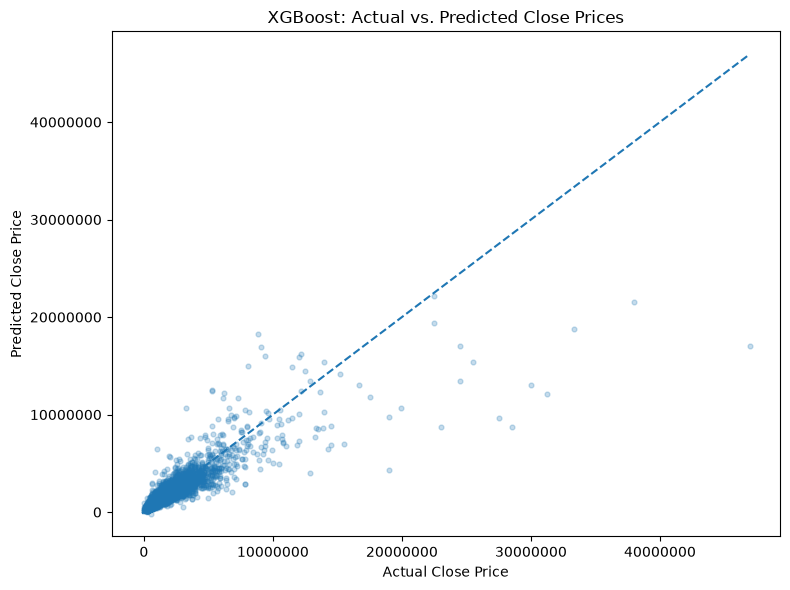

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    test_comparison["Actual"],
    test_comparison["Predicted"],
    alpha=0.25,
    s=12,
)

plot_min = min(
    test_comparison["Actual"].min(),
    test_comparison["Predicted"].min(),
)

plot_max = max(
    test_comparison["Actual"].max(),
    test_comparison["Predicted"].max(),
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("XGBoost: Actual vs. Predicted Close Prices")
plt.ticklabel_format(
    style="plain",
    axis="both",
)

plt.tight_layout()
plt.show()

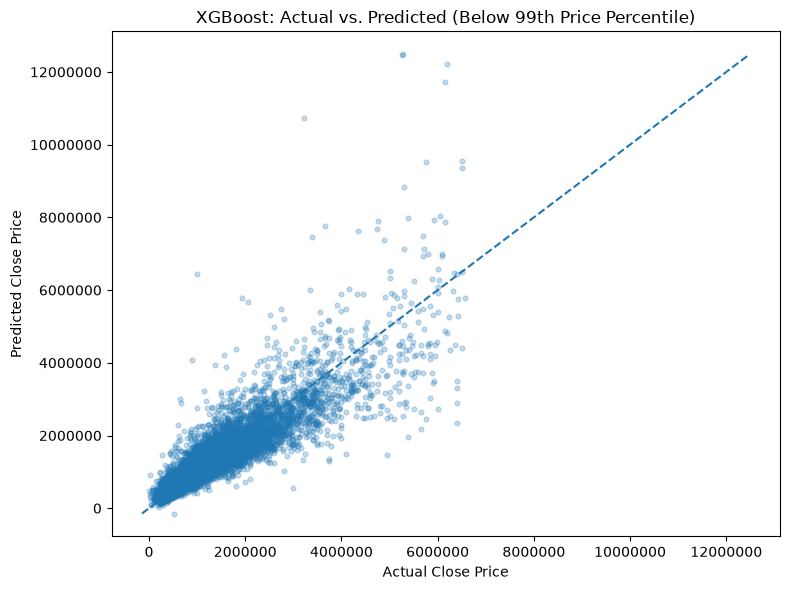

In [30]:
price_limit = test_comparison["Actual"].quantile(0.99)

regular_market_comparison = test_comparison[
    test_comparison["Actual"] <= price_limit
].copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    regular_market_comparison["Actual"],
    regular_market_comparison["Predicted"],
    alpha=0.25,
    s=12,
)

plot_min = min(
    regular_market_comparison["Actual"].min(),
    regular_market_comparison["Predicted"].min(),
)

plot_max = max(
    regular_market_comparison["Actual"].max(),
    regular_market_comparison["Predicted"].max(),
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title(
    "XGBoost: Actual vs. Predicted "
    "(Below 99th Price Percentile)"
)

plt.ticklabel_format(
    style="plain",
    axis="both",
)

plt.tight_layout()
plt.show()

In [31]:
test_comparison["Price Segment"] = pd.qcut(
    test_comparison["Actual"],
    q=5,
    labels=[
        "Lowest 20%",
        "20%–40%",
        "40%–60%",
        "60%–80%",
        "Highest 20%",
    ],
    duplicates="drop",
)

segment_results = (
    test_comparison
    .groupby(
        "Price Segment",
        observed=True,
    )
    .agg(
        Number_of_Homes=("Actual", "size"),
        Median_Actual_Price=("Actual", "median"),
        Mean_Absolute_Error=("Absolute Error", "mean"),
        Median_Absolute_Error=("Absolute Error", "median"),
        Mean_APE=("Absolute Percentage Error", "mean"),
        Median_APE=("Absolute Percentage Error", "median"),
    )
    .reset_index()
)

display(
    segment_results.style.format({
        "Number_of_Homes": "{:,.0f}",
        "Median_Actual_Price": "${:,.0f}",
        "Mean_Absolute_Error": "${:,.0f}",
        "Median_Absolute_Error": "${:,.0f}",
        "Mean_APE": "{:.2f}%",
        "Median_APE": "{:.2f}%",
    })
)

,Price Segment,Number_of_Homes,Median_Actual_Price,Mean_Absolute_Error,Median_Absolute_Error,Mean_APE,Median_APE
0,Lowest 20%,"2,616","$449,000","$120,127","$78,690",68.12%,17.86%
1,20%–40%,"2,546","$699,000","$124,808","$85,097",18.17%,12.30%
2,40%–60%,"2,560","$925,000","$154,188","$105,997",16.48%,11.34%
3,60%–80%,"2,560","$1,340,000","$227,749","$170,071",16.74%,12.59%
4,Highest 20%,"2,571","$2,398,000","$732,468","$429,376",20.51%,17.45%


In [32]:
luxury_threshold = y_development.quantile(0.95)

regular_mask = test_comparison["Actual"] < luxury_threshold
luxury_mask = test_comparison["Actual"] >= luxury_threshold

regular_metrics = calculate_metrics(
    test_comparison.loc[regular_mask, "Actual"],
    test_comparison.loc[regular_mask, "Predicted"],
)

luxury_metrics = calculate_metrics(
    test_comparison.loc[luxury_mask, "Actual"],
    test_comparison.loc[luxury_mask, "Predicted"],
)

luxury_comparison_df = pd.DataFrame([
    {
        "Segment": "Regular Homes",
        "Number of Homes": regular_mask.sum(),
        **regular_metrics,
    },
    {
        "Segment": "Luxury Homes",
        "Number of Homes": luxury_mask.sum(),
        **luxury_metrics,
    },
])

print(
    f"Luxury threshold based on the development "
    f"95th percentile: ${luxury_threshold:,.0f}"
)

display(
    luxury_comparison_df.style.format({
        "Number of Homes": "{:,.0f}",
        "R2": "{:.4f}",
        "RMSE": "${:,.0f}",
        "MAE": "${:,.0f}",
        "MAPE": "{:.2f}%",
        "MdAPE": "{:.2f}%",
    })
)

Luxury threshold based on the development 95th percentile: $3,200,000


,Segment,Number of Homes,R2,RMSE,MAE,MAPE,MdAPE
0,Regular Homes,"12,151",0.7382,"$311,301","$196,923",28.39%,13.77%
1,Luxury Homes,702,0.5097,"$2,933,042","$1,567,137",24.70%,21.12%


In [33]:
largest_errors = (
    test_comparison
    .sort_values(
        "Absolute Error",
        ascending=False,
    )
    .head(20)
)

display(
    largest_errors.style.format({
        "Actual": "${:,.0f}",
        "Predicted": "${:,.0f}",
        "Error": "${:,.0f}",
        "Absolute Error": "${:,.0f}",
        "Absolute Percentage Error": "{:.2f}%",
    })
)

,Actual,Predicted,Error,Absolute Error,Absolute Percentage Error,Price Segment
9430,"$46,950,000","$16,987,314","$-29,962,686","$29,962,686",63.82%,Highest 20%
355,"$28,500,000","$8,737,734","$-19,762,266","$19,762,266",69.34%,Highest 20%
6544,"$31,250,000","$12,147,807","$-19,102,193","$19,102,193",61.13%,Highest 20%
6952,"$27,500,000","$9,646,163","$-17,853,837","$17,853,837",64.92%,Highest 20%
4885,"$29,995,000","$13,013,656","$-16,981,344","$16,981,344",56.61%,Highest 20%
3259,"$38,000,000","$21,565,850","$-16,434,150","$16,434,150",43.25%,Highest 20%
7279,"$19,000,000","$4,321,703","$-14,678,297","$14,678,297",77.25%,Highest 20%
11546,"$33,333,333","$18,829,154","$-14,504,179","$14,504,179",43.51%,Highest 20%
10968,"$23,000,000","$8,711,527","$-14,288,473","$14,288,473",62.12%,Highest 20%
8691,"$24,500,000","$13,446,125","$-11,053,875","$11,053,875",45.12%,Highest 20%


In [34]:
feature_importance_df = pd.DataFrame({
    "Feature": X_development.columns,
    "Importance": final_xgb_model.feature_importances_,
})

feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(20))

,Feature,Importance
0,BathroomsTotalInteger,0.0743
1,LivingArea,0.0598
2,MLSAreaMajor_MCTO - Montecito,0.0522
3,MLSAreaMajor_C01 - Beverly Hills,0.0490
4,MLSAreaMajor_699 - Not Defined,0.0357
5,MLSAreaMajor_C06 - Brentwood,0.0256
6,MLSAreaMajor_N26 - Newport Coast,0.0255
7,MLSAreaMajor_CS - Corona Del Mar - Spyglass,0.0220
8,MLSAreaMajor_C14 - Santa Monica,0.0190
9,Longitude,0.0170


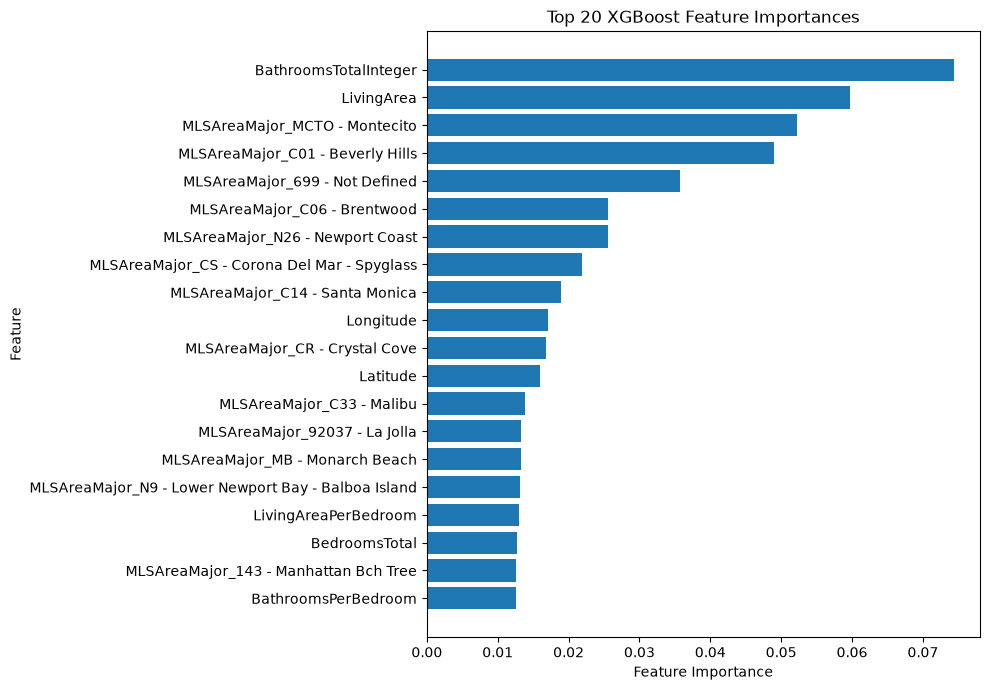

In [35]:
top_features = feature_importance_df.head(20).sort_values(
    "Importance",
    ascending=True,
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

In [36]:
previous_model_results = [
    {
        "Model": "Linear Regression",
        "Test R2": 0.494344,
        "Test RMSE": 1193534,
        "Test MAE": np.nan,
        "Test MAPE": 31.1266,
        "Test MdAPE": 18.0139,
    },
    {
        "Model": "Random Forest",
        "Test R2": 0.503368,
        "Test RMSE": 1182835,
        "Test MAE": np.nan,
        "Test MAPE": 19.6926,
        "Test MdAPE": 9.6540,
    },
    {
        "Model": "XGBoost",
        "Test R2": test_metrics["R2"],
        "Test RMSE": test_metrics["RMSE"],
        "Test MAE": test_metrics["MAE"],
        "Test MAPE": test_metrics["MAPE"],
        "Test MdAPE": test_metrics["MdAPE"],
    },
]

model_comparison_df = pd.DataFrame(
    previous_model_results
)

display(
    model_comparison_df.style.format({
        "Test R2": "{:.4f}",
        "Test RMSE": "${:,.0f}",
        "Test MAE": "${:,.0f}",
        "Test MAPE": "{:.2f}%",
        "Test MdAPE": "{:.2f}%",
    })
)

,Model,Test R2,Test RMSE,Test MAE,Test MAPE,Test MdAPE
0,Linear Regression,0.4943,"$1,193,534",$nan,31.13%,18.01%
1,Random Forest,0.5034,"$1,182,835",$nan,19.69%,9.65%
2,XGBoost,0.7622,"$749,317","$271,761",28.18%,14.05%


In [37]:
OUTPUT_DIRECTORY = Path("outputs")
OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

validation_results_df.to_csv(
    OUTPUT_DIRECTORY / "xgboost_validation_results.csv",
    index=False,
)

final_metrics_df.to_csv(
    OUTPUT_DIRECTORY / "xgboost_final_metrics.csv",
    index=False,
)

test_comparison.to_csv(
    OUTPUT_DIRECTORY / "xgboost_test_predictions.csv",
    index=False,
)

feature_importance_df.to_csv(
    OUTPUT_DIRECTORY / "xgboost_feature_importance.csv",
    index=False,
)

model_comparison_df.to_csv(
    OUTPUT_DIRECTORY / "model_comparison.csv",
    index=False,
)

print("Results saved to:")
for output_file in OUTPUT_DIRECTORY.iterdir():
    print(f"- {output_file}")

Results saved to:
- outputs/xgboost_test_predictions.csv
- outputs/model_comparison.csv
- outputs/xgboost_feature_importance.csv
- outputs/xgboost_validation_results.csv
- outputs/xgboost_final_metrics.csv


## Interpretation
The XGBoost model performed reasonably well for regular homes, achieving an R² of 0.794 and an MdAPE of 11.56%. However, performance declined substantially for luxury homes above $3.175 million, where R² fell to 0.159 and RMSE increased to approximately $4.69 million. This indicates that the weak overall test performance was primarily driven by a small number of high-priced properties rather than broad prediction failure across the housing market.

## LightGBM Model
This model uses the same development/validation split, held-out test set, and evaluation metrics as XGBoost for a fair comparison.

In [38]:
lightgbm_specs = [
    {"Model": "LightGBM 1", "num_leaves": 31, "max_depth": -1, "learning_rate": 0.05, "n_estimators": 400},
    {"Model": "LightGBM 2", "num_leaves": 63, "max_depth": -1, "learning_rate": 0.05, "n_estimators": 400},
    {"Model": "LightGBM 3", "num_leaves": 31, "max_depth": 8, "learning_rate": 0.10, "n_estimators": 300},
    {"Model": "LightGBM 4", "num_leaves": 63, "max_depth": 10, "learning_rate": 0.05, "n_estimators": 500},
]

In [39]:
def build_lightgbm(spec):
    return LGBMRegressor(objective="regression", n_estimators=spec["n_estimators"], learning_rate=spec["learning_rate"], num_leaves=spec["num_leaves"], max_depth=spec["max_depth"], subsample=0.8, colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

In [42]:
# LightGBM rejects special JSON characters in feature names. Preserve the
# data and order, but use safe internal names for LightGBM only.
original_lgb_feature_names = X_development.columns.to_list()
safe_lgb_feature_names = [f"feature_{i}" for i in range(X_development.shape[1])]
X_lgb_development = X_development.copy()
X_lgb_test = X_test.copy()
X_lgb_development.columns = safe_lgb_feature_names
X_lgb_test.columns = safe_lgb_feature_names

X_lgb_train, X_lgb_validation, y_lgb_train, y_lgb_validation = train_test_split(
    X_lgb_development, y_development, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE
)

lightgbm_validation = []
for spec in lightgbm_specs:
    model = build_lightgbm(spec)
    started = time.time()
    model.fit(X_lgb_train, y_lgb_train)
    train_metrics, _ = evaluate_model(model, X_lgb_train, y_lgb_train, "Training")
    validation_metrics, _ = evaluate_model(model, X_lgb_validation, y_lgb_validation, "Validation")
    lightgbm_validation.append({**spec, "Training Seconds": time.time() - started, **{f"Train {k}": v for k, v in train_metrics.items() if k != "Split"}, **{f"Validation {k}": v for k, v in validation_metrics.items() if k != "Split"}})

lightgbm_validation_df = pd.DataFrame(lightgbm_validation).sort_values(["Validation R2", "Validation MdAPE"], ascending=[False, True]).reset_index(drop=True)
best_lightgbm = lightgbm_validation_df.iloc[0]
final_lightgbm = build_lightgbm(best_lightgbm)
final_lightgbm.fit(X_lgb_development, y_development)
lightgbm_development_metrics, _ = evaluate_model(final_lightgbm, X_lgb_development, y_development, "Development")
lightgbm_test_metrics, lightgbm_test_predictions = evaluate_model(final_lightgbm, X_lgb_test, y_test, "Test")
lightgbm_final_metrics_df = pd.DataFrame([{"Model": "Final LightGBM", **lightgbm_development_metrics}, {"Model": "Final LightGBM", **lightgbm_test_metrics}])
lightgbm_predictions_df = pd.DataFrame({"Actual": y_test.to_numpy(), "Predicted": lightgbm_test_predictions})
lightgbm_predictions_df["Error"] = lightgbm_predictions_df["Predicted"] - lightgbm_predictions_df["Actual"]
lightgbm_predictions_df["Absolute Error"] = lightgbm_predictions_df["Error"].abs()
lightgbm_predictions_df["Absolute Percentage Error"] = lightgbm_predictions_df["Absolute Error"] / lightgbm_predictions_df["Actual"] * 100
lightgbm_importance_df = pd.DataFrame({"Feature": original_lgb_feature_names, "Importance": final_lightgbm.feature_importances_}).sort_values("Importance", ascending=False).reset_index(drop=True)
lightgbm_validation_df.to_csv(OUTPUT_DIRECTORY / "lightgbm_validation_results.csv", index=False)
lightgbm_final_metrics_df.to_csv(OUTPUT_DIRECTORY / "lightgbm_final_metrics.csv", index=False)
lightgbm_predictions_df.to_csv(OUTPUT_DIRECTORY / "lightgbm_test_predictions.csv", index=False)
lightgbm_importance_df.to_csv(OUTPUT_DIRECTORY / "lightgbm_feature_importance.csv", index=False)
display(lightgbm_validation_df)
display(lightgbm_final_metrics_df)

,Model,num_leaves,max_depth,learning_rate,n_estimators,Training Seconds,Train R2,Train RMSE,Train MAE,Train MAPE,Train MdAPE,Validation R2,Validation RMSE,Validation MAE,Validation MAPE,Validation MdAPE
0,LightGBM 4,63,10,0.0500,500,10.0265,0.9377,"335,186.9817","174,101.4819",14.7135,10.1532,0.7712,"674,620.3405","216,926.1383",16.4599,10.7859
1,LightGBM 2,63,-1,0.0500,400,16.4849,0.9536,"289,183.8035","156,583.7859",13.8612,9.5912,0.7707,"675,366.1829","212,292.5361",15.9901,10.5254
2,LightGBM 3,31,8,0.1000,300,6.4295,0.9254,"366,662.0951","191,773.4524",16.2623,11.2427,0.7707,"675,389.4661","228,848.0109",17.6585,11.9122
3,LightGBM 1,31,-1,0.0500,400,12.1051,0.9307,"353,462.6495","189,537.9586",16.4671,11.3766,0.7700,"676,327.9429","225,109.0991",17.5410,11.8603


,Model,R2,RMSE,MAE,MAPE,MdAPE,Split
0,Final LightGBM,0.9330,"351,055.8566","177,669.2787",14.9843,10.2759,Development
1,Final LightGBM,0.7650,"744,924.3420","236,660.9632",23.8591,11.0998,Test
